In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#!{sys.executable} -m pip install --force-reinstall "numpy<2.0" "opencv-python<4.10" scikit-learn

In [ ]:
import torch
import sys

# 1. 필수 라이브러리 설치
# (uv를 쓰신다면 uv add로 대체 가능합니다!)
# !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
# !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

# 2. GPU 최적화 설정 (Ampere 아키텍처 이상 추천)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# bfloat16 컨텍스트 설정 (메모리 절약)
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [ ]:
!pip install iopath
!pip install triton

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np



!git clone https://github.com/facebookresearch/sam3.git
!pip install -e sam3

import sam3.sam3 as sam3
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results


fatal: destination path 'sam3' already exists and is not an empty directory.
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15720 sha256=6d979cbd171ecf3914bf2111b617ba9914fbf2479aaa1dbed177de9511c9c691
  Stored in directory: /tmp/pip-ephem-wheel-cache-x3eod_yj/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0


/content/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
from huggingface_hub import login
login(token="hf_REDACTED")


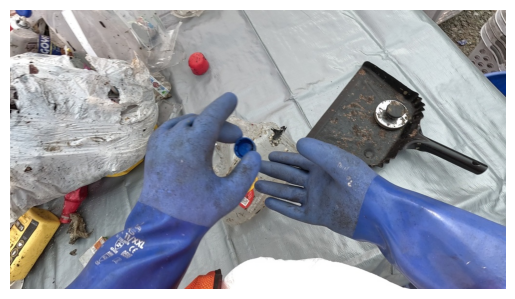

In [ ]:

import pandas as pd
import cv2
import matplotlib.pyplot as plt

# Paste your copied path here
file_path = '/content/drive/MyDrive/plastics_dataset/frames/GX010023/GX010023__frame_000001.jpg'


# 1. Read the image using OpenCV
img = cv2.imread(file_path)

# 2. Convert from BGR to RGB so Matplotlib displays it correctly
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Display the image
plt.imshow(img_rgb)
plt.axis('off')  # Hides the grid and axes numbers
plt.show()


In [ ]:
# 모델 빌드 (경로는 본인 환경에 맞게 수정)
# bpe_path는 토크나이저 관련 파일입니다.
sam3_root = "sam3/sam3" # sam3 설치 경로
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"

model = build_sam3_image_model(bpe_path=bpe_path)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

In [ ]:
#imgNumber: number that identifies each image in the dataset file
#testPrompt: prompt that we give to SAM3
#gets individual image provided by imgNumber, then segment the image using the input prompt.

def image_load_and_test(imgNumber, testPrompt ):
    imagePath = f"/content/drive/MyDrive/plastics_dataset/frames/GX010023/GX010023__frame_{imgNumber}.jpg"
    imgTest = Image.open(imagePath)

    processor = Sam3Processor(model, confidence_threshold=0.5)
    inference_state = processor.set_image(imgTest)
    # 텍스트로 객체 찾기
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt=testPrompt)

    print(inference_state.keys())
    print(inference_state["boxes"])
    boxes = inference_state["boxes"]

    plot_results(imgTest, inference_state)


In [ ]:
#imgNumber: number that identifies each image in the dataset file
#testPrompt: prompt that we give to SAM3
#gets individual image provided by imgNumber, then segment the image using the input prompt.

#outputBoxes = None
def image_load_and_test(imgNumber, testPrompt ):
    imagePath = f"/content/drive/MyDrive/plastics_dataset/frames/GX010023/GX010023__frame_{imgNumber}.jpg"
    imgTest = Image.open(imagePath)

    processor = Sam3Processor(model, confidence_threshold=0.5)
    inference_state = processor.set_image(imgTest)
    # 텍스트로 객체 찾기
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt=testPrompt)

    print(inference_state.keys())
    print(inference_state["boxes"])
    boxes = inference_state["boxes"]

    #plot_results(imgTest, inference_state)

    if len(boxes) == 0:
        return None


    hand1 = boxes[0]
    hand2 = None
    if len(boxes) > 1:
        hand2 = boxes[1]
    if len(boxes) > 2:
        size1 = 0;
        size2 = 0;
        for box in boxes:
            area = (box[2] - box[0]) * (box[3] - box[1])

            if area > min(size1, size2):
                if size2 > size1:
                    size1 = size2
                    hand1 = hand2

                size2 = area
                hand2 = box

    # Determine crop coordinates
    x1 = float(hand1[0])
    y1 = float(hand1[1])
    x2 = float(hand1[2])
    y2 = float(hand1[3])
    if hand2 is not None:
        x1 = min(float(hand1[0]), float(hand2[0]))
        y1 = min(float(hand1[1]), float(hand2[1]))
        x2 = max(float(hand1[2]), float(hand2[2]))
        y2 = max(float(hand1[3]), float(hand2[3]))


    cropped = imgTest
    if len(boxes) <= 2:
        paddingX = imgTest.width*0.5
        paddingY = imgTest.height*0.5
        # Add padding
        x1 -= paddingX
        y1 -= paddingY
        x2 += paddingX
        y2 += paddingY

        # Keep crop inside image
        img_w, img_h = imgTest.size

        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(img_w, int(x2))
        y2 = min(img_h, int(y2))

        cropped = imgTest.crop((x1, y1, x2, y2))

    else:
        #crop the image so the image excludes the other hands (that are not the biggest hands)

        other_boxes = []

        for box in boxes:
            if not ((box == hand1).all() if hasattr(box, "all") else box == hand1) and \
               not ((box == hand2).all() if hasattr(box, "all") else box == hand2):
                other_boxes.append(box)

        # Start with selected hands' bounding box
        crop_x1 = x1
        crop_y1 = y1
        crop_x2 = x2
        crop_y2 = y2

        # Adjust crop boundaries to avoid other hands
        for box in other_boxes:
            ox1, oy1, ox2, oy2 = map(float, box)

            # Other hand is to the right of selected hands
            if ox1 >= crop_x2:
                crop_x2 = min(crop_x2, ox1)

            # Other hand is to the left of selected hands
            elif ox2 <= crop_x1:
                crop_x1 = max(crop_x1, ox2)

            # Other hand is below selected hands
            elif oy1 >= crop_y2:
                crop_y2 = min(crop_y2, oy1)

            # Other hand is above selected hands
            elif oy2 <= crop_y1:
                crop_y1 = max(crop_y1, oy2)


        # Clamp to image size
        img_w, img_h = imgTest.size

        crop_x1 = max(0, int(crop_x1))
        crop_y1 = max(0, int(crop_y1))
        crop_x2 = min(img_w, int(crop_x2))
        crop_y2 = min(img_h, int(crop_y2))

        cropped = imgTest.crop((crop_x1, crop_y1, crop_x2, crop_y2))

    plt.imshow(cropped)
    plt.axis("off")
    plt.show()


In [ ]:
# @title
#if single set of hands --> crop image by making those hands as a center point
#if multiple hands --> find biggest hands and crop image so it doesn't include the other hands
def crop_image(imgToCrop, boxes, padding = 50):
    if len(boxes) == 0:
        return None
    hand1 = boxes[0]
    hand2 = None
    if len(boxes) > 1:
        hand2 = boxes[1]
    if len(boxes) > 2:
        size1 = 0;
        size2 = 0;
        for i in range(len(boxes)):
            box = boxes[i]
            width = box[2] - box[0]
            height = box[3] - box[1]
            area = width * height

            if area > min(size1, size2):
                if size2 > size1:
                    size1 = size2
                    hand1 = hand2

                size2 = area
                hand2 = box

    # Determine crop coordinates
    if hand2 is None:
        x1 = hand1[0]
        y1 = hand1[1]
        x2 = hand1[2]
        y2 = hand1[3]
    else:
        x1 = min(hand1[0], hand2[0])
        y1 = min(hand1[1], hand2[1])
        x2 = max(hand1[2], hand2[2])
        y2 = max(hand1[3], hand2[3])

    # Add padding
    x1 -= padding
    y1 -= padding
    x2 += padding
    y2 += padding

    # Keep crop inside image
    img_w, img_h = imgToCrop.size

    x1 = max(0, int(x1))
    y1 = max(0, int(y1))
    x2 = min(img_w, int(x2))
    y2 = min(img_h, int(y2))

    print (imgToCrop.crop((x1, y1, x2, y2)))

dict_keys(['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores'])
tensor([[ 4.1381e+02, -1.0969e+00,  4.8885e+02,  6.1823e+01],
        [ 7.1189e+02,  4.1865e+02,  8.7423e+02,  5.4661e+02],
        [ 2.7867e+02,  4.3848e+02,  4.2915e+02,  5.5782e+02],
        [ 2.4229e+02,  4.3894e+02,  4.2873e+02,  5.7587e+02],
        [ 2.7649e+02, -2.1648e+00,  3.4913e+02,  3.5780e+01],
        [ 7.1445e+02,  4.2009e+02,  9.6029e+02,  5.7490e+02],
        [ 4.1386e+02, -3.2421e-01,  5.3727e+02,  6.2234e+01]], device='cuda:0')
found 7 object(s)


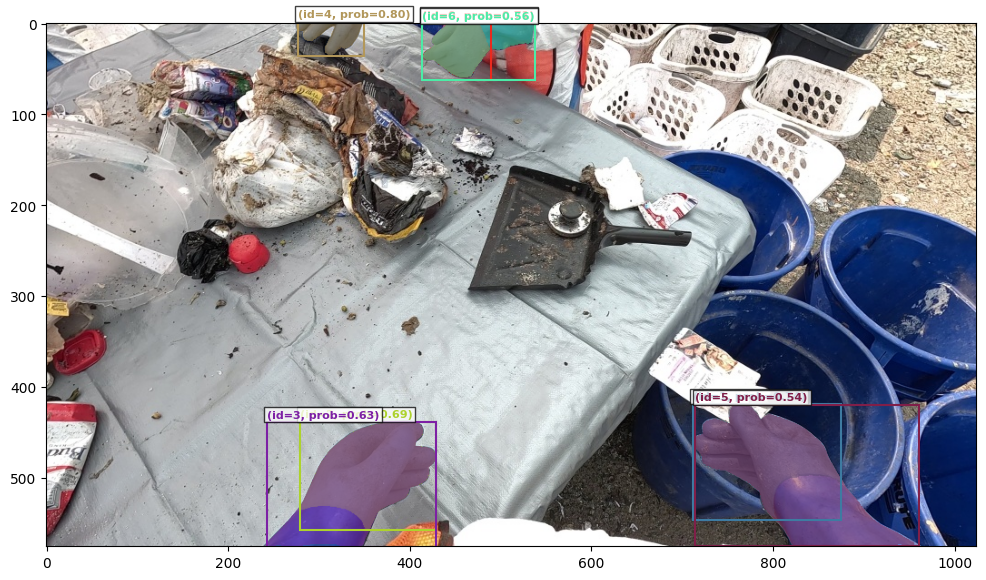

In [ ]:
image_load_and_test("000200", "hands")


In [ ]:
# 텍스트로 객체 찾기
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="waste")

img0 = Image.open(image_path)
plot_results(img0, inference_state)


NameError: name 'processor' is not defined

In [ ]:
print(box_input_xywh)

In [ ]:
# Here the box is in  (x,y,w,h) format, where (x,y) is the top left corner.
box_input_xywh = torch.tensor([480.0, 290.0, 110.0, 360.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)


norm_box_cxcywh = normalize_bbox(box_input_cxcywh, img0.width, img0.height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh)

processor.reset_all_prompts(inference_state)
inference_state = processor.add_geometric_prompt(
    state=inference_state, box=norm_box_cxcywh, label=True
)


In [ ]:
plot_results(img0, inference_state)


In [ ]:
box_input_xywh = [[480.0, 290.0, 110.0, 360.0], [370.0, 280.0, 115.0, 375.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh).view(-1,4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()

box_labels = [True, False]

processor.reset_all_prompts(inference_state)

for box, label in zip(norm_boxes_cxcywh, box_labels):
    inference_state = processor.add_geometric_prompt(
        state=inference_state, box=box, label=label
    )

img0 = Image.open(image_path)
image_with_box = img0
for i in range(len(box_input_xywh)):
    if box_labels[i] == 1:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)
    image_with_box = draw_box_on_image(image_with_box, box_input_xywh[i], color)
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()


In [ ]:
plot_results(img0, inference_state)


In [ ]:
# 변수명이 results라고 가정합니다 (inference_state 혹은 predict 결과)

# (1) 마스크 키 찾기 (버전마다 키 값이 다를 수 있어 예외처리)
if 'pred_masks' in results:
    masks_tensor = results['pred_masks']
elif 'masks' in results:
    masks_tensor = results['masks']
else:
    print("마스크 키를 못 찾겠어요! keys:", results.keys())
    masks_tensor = None

if masks_tensor is not None:
    # (2) GPU 텐서 -> CPU Numpy 배열로 변환 (필수!)
    # .detach(): 그래디언트 계산 끊기
    # .cpu(): GPU 메모리에서 내리기
    # .numpy(): 넘파이 배열로 변환
    masks_np = masks_tensor.detach().cpu().numpy()

    # (3) Threshold 적용 (옵션)
    # SAM 결과는 보통 로짓(logit)값이므로 0보다 크면 마스크로 간주
    masks_np = masks_np > 0

    print(f"Mask Shape: {masks_np.shape}")
    # 이후 OpenCV 등을 사용해 시각화하거나 저장하면 됩니다.
